# DESAFIO PROFESIONAL AIRBNB - DIGITAL HOUSE - DATA SCIENCE#

# ETAPA 1 y 2 :  EDA y Limpieza y transformación de datos


### 1. Carga de datos

In [ ]:
# --- 1. CONFIGURACIÓN DEL ENTORNO ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# --- 2. CONEXIÓN CON DRIVE ---

drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# --- 3. DEFINICIÓN DE RUTAS Y CARGA ---

base_path = '/content/drive/MyDrive/Desafio profesional DH/Datasets/'

print("⏳ Cargando datasets desde Drive...")

try:
    df_calendar = pd.read_csv(base_path + 'calendar.csv')
    df_listings = pd.read_csv(base_path + 'listings.csv')
    df_reviews = pd.read_csv(base_path + 'reviews.csv')

    print("✅ Carga exitosa!")
    print(f"Dimensiones Listings: {df_listings.shape}")
    print(f"Dimensiones Calendar: {df_calendar.shape}")
    print(f"Dimensiones Reviews:  {df_reviews.shape}")
except FileNotFoundError:
    print(" Error: Asegurate de que los archivos CSV existan en la ruta especificada.")
except Exception as e:
    print(f"Ocurrió un error al cargar los datasets: {e}")

⏳ Cargando datasets desde Drive...


/tmp/ipython-input-404/2575158849.py:9: DtypeWarning: Columns (61,62,95) have mixed types. Specify dtype option on import or set low_memory=False.
  df_listings = pd.read_csv(base_path + 'listings.csv')


✅ Carga exitosa!
Dimensiones Listings: (23729, 106)
Dimensiones Calendar: (8661286, 7)
Dimensiones Reviews:  (387099, 6)


## 1.1 Limpieza preliminar

### Tabla Calendar





In [ ]:
df_calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8661286 entries, 0 to 8661285
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   listing_id      int64  
 1   date            object 
 2   available       object 
 3   price           object 
 4   adjusted_price  object 
 5   minimum_nights  float64
 6   maximum_nights  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 462.6+ MB


In [ ]:
df_calendar.head()

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,50778,2020-04-26,f,"$2,655.00","$2,655.00",5.0,1125.0
1,133654,2020-04-27,t,"$1,150.00","$1,150.00",4.0,1125.0
2,133654,2020-04-28,t,"$1,150.00","$1,150.00",4.0,1125.0
3,133654,2020-04-29,t,"$1,150.00","$1,150.00",4.0,1125.0
4,133654,2020-04-30,t,"$1,150.00","$1,150.00",4.0,1125.0


Tras usar los metodos .info y .head, detecte inconsistencias en el formato de variables importantes:

* como Precios (price) que actualmente son de tipo objeto, ya que tienen el
simbolo "$" y comas separando los miles. Esta variable deberia estar en float parap oder hacer calculos.


*   La variable Fechas (date) esta en formato object (texto) y hay que convertirla en datetime para habilitar analisis de series de tiempo

*   El campo disponibilidad (available) estan con valores "t" y "f", como objetos y los voy a transformar en booleanos True/False para facilitar el calculo de tasas de ocupación



In [ ]:
# =========================
# 1)  LIMPIEZA CALENDAR
# =========================
def clean_calendar(df_calendar: pd.DataFrame) -> pd.DataFrame:
    df = df_calendar.copy()

    # Tipos
    if "listing_id" in df.columns:
        df["listing_id"] = pd.to_numeric(df["listing_id"], errors="coerce").astype("Int64")

    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # Disponibilidad: 't'/'f' -> bool
    if "available" in df.columns:
        df["available"] = df["available"].map({"t": True, "f": False})

    # Precios: "$1,200.00" -> float
    for c in ["price", "adjusted_price"]:
        if c in df.columns:
            df[c] = (
                df[c]
                .astype(str)
                .str.replace(r"[\$,]", "", regex=True)
                .replace("nan", pd.NA)
            )
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Noches: a numérico (nullable)
    for c in ["minimum_nights", "maximum_nights"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")

    # etiqueta estilo repo
    df["available_label"] = df.get("available").map({True: "Available", False: "Rented"}) if "available" in df.columns else None

    return df

In [ ]:
df_calendar = clean_calendar(df_calendar)

print("✅ dtypes luego de limpiar:")
print(df_calendar.dtypes)

display(df_calendar.head())
df_calendar.info()

✅ dtypes luego de limpiar:
listing_id                  Int64
date               datetime64[ns]
available                    bool
price                     float64
adjusted_price            float64
minimum_nights              Int64
maximum_nights              Int64
available_label            object
dtype: object


,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights,available_label
0,50778,2020-04-26,False,2655.0,2655.0,5,1125,Rented
1,133654,2020-04-27,True,1150.0,1150.0,4,1125,Available
2,133654,2020-04-28,True,1150.0,1150.0,4,1125,Available
3,133654,2020-04-29,True,1150.0,1150.0,4,1125,Available
4,133654,2020-04-30,True,1150.0,1150.0,4,1125,Available


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8661286 entries, 0 to 8661285
Data columns (total 8 columns):
 #   Column           Dtype         
---  ------           -----         
 0   listing_id       Int64         
 1   date             datetime64[ns]
 2   available        bool          
 3   price            float64       
 4   adjusted_price   float64       
 5   minimum_nights   Int64         
 6   maximum_nights   Int64         
 7   available_label  object        
dtypes: Int64(3), bool(1), datetime64[ns](1), float64(2), object(1)
memory usage: 495.6+ MB


### Tabla Listings


In [ ]:
df_listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23729 entries, 0 to 23728
Columns: 106 entries, id to reviews_per_month
dtypes: float64(23), int64(21), object(62)
memory usage: 19.2+ MB


In [ ]:
# Ver todos los nombres de columnas para elegir cuáles nos sirven (tiene 186 campos)
print(df_listings.columns.tolist())

['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary', 'space', 'description', 'experiences_offered', 'neighborhood_overview', 'notes', 'transit', 'access', 'interaction', 'house_rules', 'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'street', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'city', 'state', 'zipcode', 'market', 'smart_location', 'country_code', 'country', 'latitude', 'longitude', 'is_location_exact', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'square_feet', 'price', 'weekly_price', 'monthly_price', '

In [ ]:
# 1) Selección de variables
columnas_inversion = [
    'id', 'name',
    'neighbourhood_cleansed', 'latitude', 'longitude',
    'price', 'security_deposit', 'cleaning_fee', 'extra_people', 'guests_included',
    'property_type', 'room_type', 'accommodates',
    'bathrooms', 'bedrooms', 'beds',
    'number_of_reviews', 'reviews_per_month',
    'review_scores_rating', 'review_scores_location',
    'availability_365',
    'host_id', 'host_is_superhost', 'host_identity_verified'
]

df_reducido = df_listings[columnas_inversion].copy()

# 2) IDs a enteros (nullable)
df_reducido["id"] = pd.to_numeric(df_reducido["id"], errors="coerce").astype("Int64")
df_reducido["host_id"] = pd.to_numeric(df_reducido["host_id"], errors="coerce").astype("Int64")

# 3) Flags -> bool
bool_map = {
    "t": True, "f": False,
    "true": True, "false": False,
    "yes": True, "no": False,
    "1": True, "0": False
}
for c in ["host_is_superhost", "host_identity_verified"]:
    if c in df_reducido.columns:
        df_reducido[c] = (
            df_reducido[c]
            .astype("string")
            .str.strip()
            .str.lower()
            .map(bool_map)
            .astype("boolean")   # boolean nullable (permite <NA>)
        )

# 4) Limpieza de moneda (VECTORIAL, sin apply, deja NaN si está mal)
money_cols = ["price", "security_deposit", "cleaning_fee", "extra_people"]
for c in money_cols:
    if c in df_reducido.columns:
        s = df_reducido[c].astype("string")
        s = s.str.replace("$", "", regex=False).str.replace(",", "", regex=False)
        df_reducido[c] = pd.to_numeric(s, errors="coerce")

# 5) Numéricos
num_cols = [
    "latitude","longitude","guests_included","accommodates","bathrooms","bedrooms","beds",
    "number_of_reviews","reviews_per_month","review_scores_rating","review_scores_location",
    "availability_365"
]
for c in num_cols:
    if c in df_reducido.columns:
        df_reducido[c] = pd.to_numeric(df_reducido[c], errors="coerce")

# conteos como Int64
for c in ["guests_included", "accommodates", "number_of_reviews", "availability_365"]:
    if c in df_reducido.columns:
        df_reducido[c] = pd.to_numeric(df_reducido[c], errors="coerce").astype("Int64")

# 6) Texto (string dtype)
for c in ["name","neighbourhood_cleansed","property_type","room_type"]:
    if c in df_reducido.columns:
        df_reducido[c] = df_reducido[c].astype("string")

print("✅ Listings reducido + limpio")
print(df_reducido.dtypes)
display(df_reducido.head())

✅ Listings reducido + limpio
id                                 Int64
name                      string[python]
neighbourhood_cleansed    string[python]
latitude                         float64
longitude                        float64
price                            Float64
security_deposit                 Float64
cleaning_fee                     Float64
extra_people                     Float64
guests_included                    Int64
property_type             string[python]
room_type                 string[python]
accommodates                       Int64
bathrooms                        float64
bedrooms                         float64
beds                             float64
number_of_reviews                  Int64
reviews_per_month                float64
review_scores_rating             float64
review_scores_location           float64
availability_365                   Int64
host_id                            Int64
host_is_superhost                boolean
host_identity_verified      

,id,name,neighbourhood_cleansed,latitude,longitude,price,security_deposit,cleaning_fee,extra_people,guests_included,...,bedrooms,beds,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_location,availability_365,host_id,host_is_superhost,host_identity_verified
0,11508,Amazing Luxurious Apt-Palermo Soho,Palermo,-34.58184,-58.42415,3983.0,0.0,3319.0,0.0,1,...,1.0,1.0,26,0.27,95.0,10.0,365,42762,True,True
1,12463,Room in Recoleta - awesome location,Recoleta,-34.59761,-58.39468,1593.0,<NA>,<NA>,0.0,1,...,1.0,1.0,20,0.16,95.0,10.0,365,48799,False,True
2,13095,Standard Room at Palermo Viejo B&B,Palermo,-34.59382,-58.42994,2987.0,<NA>,<NA>,0.0,1,...,1.0,1.0,1,0.06,100.0,10.0,365,50994,False,False
3,13096,Standard Room in Palermo Viejo B&B,Palermo,-34.59398,-58.42853,2987.0,19914.0,1328.0,0.0,1,...,1.0,2.0,0,NaN,NaN,NaN,365,50994,False,False
4,13097,Standard Room at Palermo Viejo B&B,Palermo,-34.59348,-58.42949,2987.0,<NA>,<NA>,996.0,1,...,1.0,2.0,66,1.89,99.0,10.0,365,50994,False,False


In [ ]:
# --- ESTRATEGIA DE IMPUTACIÓN DE NULOS ---
print("--- Antes de la limpieza final ---")
print(f"Filas totales: {df_reducido.shape[0]}")
print(f"Nulos en reviews_per_month: {df_reducido['reviews_per_month'].isnull().sum()}")

# 1) reviews_per_month: asegurar numérico y completar nulos con 0
df_reducido["reviews_per_month"] = pd.to_numeric(df_reducido["reviews_per_month"], errors="coerce")
df_reducido["reviews_per_month"] = df_reducido["reviews_per_month"].fillna(0)

# 2) Estructurales: medir impacto antes de borrar
cols_estructurales = ["bathrooms", "bedrooms", "beds"]
n_before = len(df_reducido)
n_missing_struct = df_reducido[cols_estructurales].isna().any(axis=1).sum()
print(f"Filas con faltantes estructurales: {n_missing_struct} ({n_missing_struct/n_before:.2%})")

# Borrar solo si realmente son pocas
if n_missing_struct / n_before < 0.01:
    df_reducido = df_reducido.dropna(subset=cols_estructurales)
    print("✅ Se eliminaron filas con faltantes estructurales (impacto bajo).")
else:
    print("⚠️ No se eliminan filas estructurales (impacto alto). Se dejan NaN para no sesgar el dataset.")

# 3) Scores: no imputar (solo medir)
nulos_rating = df_reducido["review_scores_rating"].isnull().sum()

print("\n--- Después de la limpieza final ---")
print(f"Filas restantes: {df_reducido.shape[0]}")
print(f"Nulos en reviews_per_month: {df_reducido['reviews_per_month'].isnull().sum()} (Debe ser 0)")
print(f"Nulos en rating: {nulos_rating} (Se dejan así a propósito)")

display(df_reducido[["price", "reviews_per_month", "beds"]].head())

--- Antes de la limpieza final ---
Filas totales: 23729
Nulos en reviews_per_month: 6507
Filas con faltantes estructurales: 239 (1.01%)
⚠️ No se eliminan filas estructurales (impacto alto). Se dejan NaN para no sesgar el dataset.

--- Después de la limpieza final ---
Filas restantes: 23729
Nulos en reviews_per_month: 0 (Debe ser 0)
Nulos en rating: 6890 (Se dejan así a propósito)


,price,reviews_per_month,beds
0,3983.0,0.27,1.0
1,1593.0,0.16,1.0
2,2987.0,0.06,1.0
3,2987.0,0.00,2.0
4,2987.0,1.89,2.0


In [ ]:
df_reducido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23729 entries, 0 to 23728
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      23729 non-null  Int64  
 1   name                    23719 non-null  string 
 2   neighbourhood_cleansed  23729 non-null  string 
 3   latitude                23729 non-null  float64
 4   longitude               23729 non-null  float64
 5   price                   23729 non-null  Float64
 6   security_deposit        15534 non-null  Float64
 7   cleaning_fee            16944 non-null  Float64
 8   extra_people            23729 non-null  Float64
 9   guests_included         23729 non-null  Int64  
 10  property_type           23729 non-null  string 
 11  room_type               23729 non-null  string 
 12  accommodates            23729 non-null  Int64  
 13  bathrooms               23667 non-null  float64
 14  bedrooms                23686 non-null

En la variable reviews_per_month se imputaron los valores faltantes con 0, ya que la ausencia de información puede interpretarse como falta de actividad reciente en términos de reseñas.

En el caso de las variables de calidad (review_scores_*), los valores nulos se mantuvieron sin imputar, dado que estos corresponden principalmente a alojamientos sin reseñas. Imputarlos podría introducir sesgos en el análisis de la percepción de calidad.

Por último, para las variables estructurales del alojamiento (beds, bathrooms, bedrooms), se eliminaron los registros con valores faltantes, ya que representaban una proporción mínima del dataset (≈1%) y su exclusión no afecta significativamente la representatividad del análisis.


### Tabla Reviews


In [ ]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387099 entries, 0 to 387098
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   listing_id     387099 non-null  int64 
 1   id             387099 non-null  int64 
 2   date           387099 non-null  object
 3   reviewer_id    387099 non-null  int64 
 4   reviewer_name  387099 non-null  object
 5   comments       386923 non-null  object
dtypes: int64(3), object(3)
memory usage: 17.7+ MB


In [ ]:
# --- LIMPIEZA DE NULOS EN REVIEWS ---

# 1. Diagnóstico previo
nulos = df_reviews['comments'].isnull().sum()
print(f"📉 Se detectaron {nulos} comentarios vacíos (NaN).")

# 2. Decisión Profesional: Eliminar (Drop)
# Para NLP, un comentario vacío no aporta valor (es ruido).
# Al ser menos del 0.05% de los datos, eliminarlos es la práctica estándar.
if nulos > 0:
    df_reviews = df_reviews.dropna(subset=['comments'])
    print(f"✅ Se han eliminado las {nulos} filas vacías.")

# 3. Verificación final
print(f"Dimensiones finales: {df_reviews.shape}")
print("Nulos restantes en comments:", df_reviews['comments'].isnull().sum())

📉 Se detectaron 176 comentarios vacíos (NaN).
✅ Se han eliminado las 176 filas vacías.
Dimensiones finales: (386923, 6)
Nulos restantes en comments: 0


Vi que habia varios registros sin comentarios (176), dado que son comentarios de analisis de texto y sentimiento, opté por eliminar los registros en lugar de imputarlos con texto.

## 1.2 Análisis univariado: Distribución de precios y outliers

--- Resumen Estadístico del Precio ---


,price
count,23729.0
mean,4014.875595
std,16075.326378
min,0.0
25%,1394.0
50%,2124.0
75%,3319.0
max,663732.0


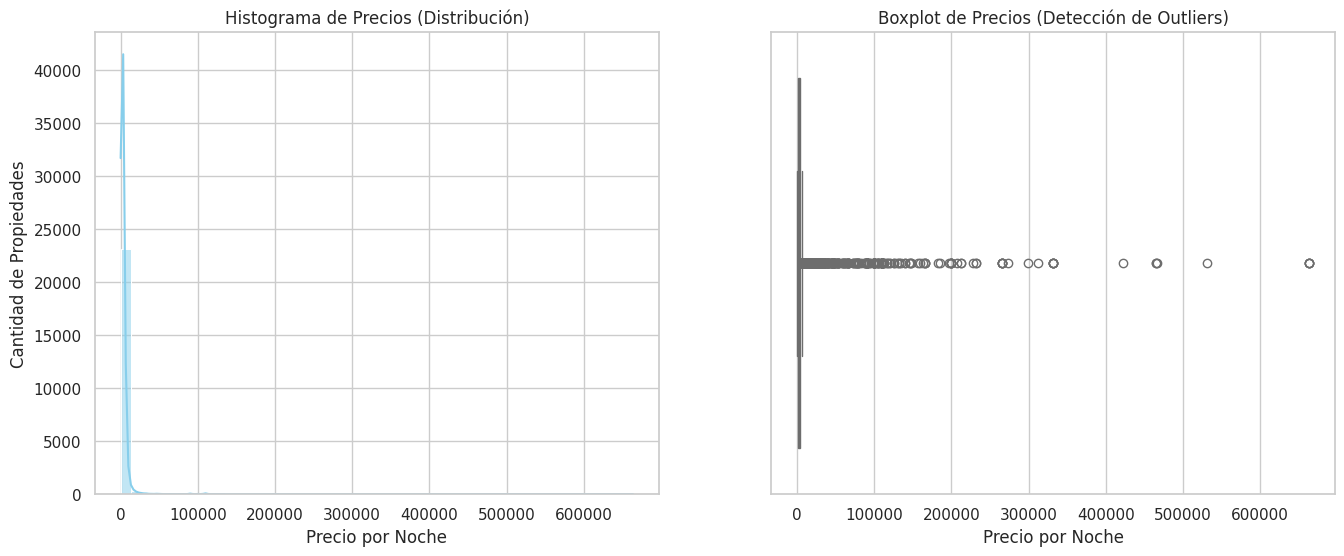

In [ ]:
# Configuración estética de los gráficos
sns.set_style("whitegrid")

# --- 1. ESTADÍSTICAS DESCRIPTIVAS ---
print("--- Resumen Estadístico del Precio ---")
# .describe() nos da media, desvío, min, max y cuartiles de un saque
display(df_reducido['price'].describe())

# --- 2. GRÁFICOS DE DISTRIBUCIÓN ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Histograma: Para ver la "forma" de los precios
sns.histplot(df_reducido['price'], bins=50, kde=True, color='skyblue', ax=ax[0])
ax[0].set_title('Histograma de Precios (Distribución)')
ax[0].set_xlabel('Precio por Noche')
ax[0].set_ylabel('Cantidad de Propiedades')

# Boxplot: Para detectar OUTLIERS
sns.boxplot(x=df_reducido['price'], color='salmon', ax=ax[1])
ax[1].set_title('Boxplot de Precios (Detección de Outliers)')
ax[1].set_xlabel('Precio por Noche')

plt.show()

Histograma: Aca se ve algo de distorsion en la distribucipn de los precios. 1. Disparidad extrema: existe una brecha entre la mediana ($2124)
 y el maximo registrado ($663.732), este segundo valor aplasta la visualizacion del histograma y no representa el mercado habitual
2. La media (4014) es casi el doble que la mediana. Esto confirma que los valores altos estan inflando el precio promedio
3. Inconsistencia de datos hay valores minimos de 0, pero no tiene sentido pq no hay alquileres gratuiros.

Por lo tando como siguiente paso, tengo que eliminar los registros con precio $0 y recortar el 1% superior de la muestra (outliers)


Boxplot: El diagrama de caja confirma la presencia de valores atipicos extremos, ya que la caja aparece comprimdia contra el eje inciial ya que los outliers estan distorsionando la escala

✂️ Cortaremos precios mayores a: $30,442.04
✅ Nuevo dataset listo: 23490 propiedades.
🗑️ Se eliminaron 239 outliers (Ceros y Mansiones extremas).


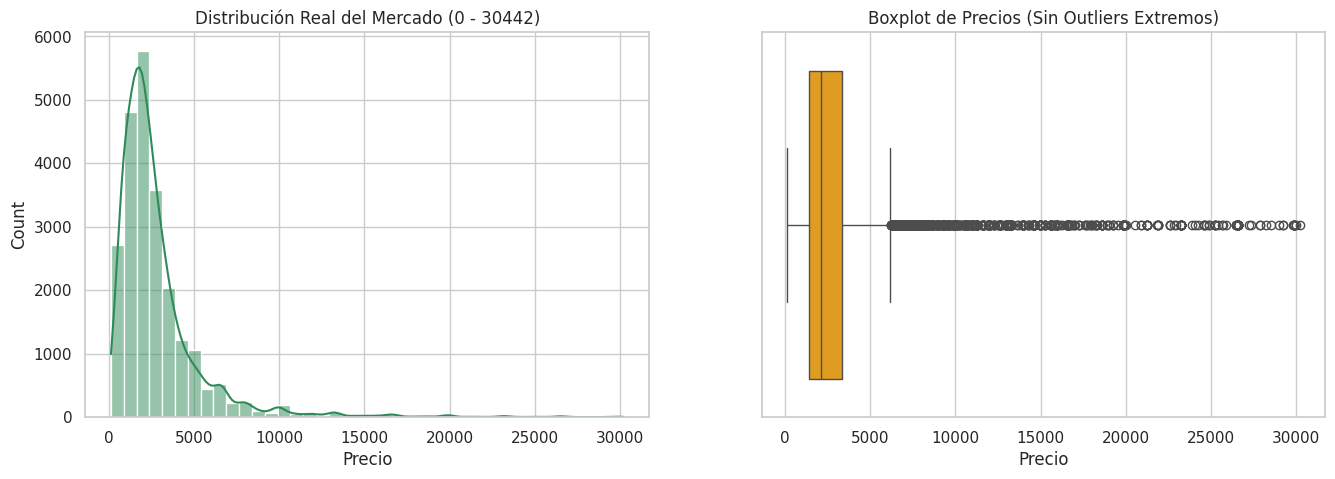


--- Estadísticas del Mercado Real ---


,price
count,23490.0
mean,2877.354917
std,2775.289738
min,133.0
25%,1394.0
50%,2124.0
75%,3319.0
max,30203.0


In [ ]:
# --- PASO 1: FILTRADO DE DATOS---

# Calculo el límite de corte (El precio donde empieza el 1% más caro)
precio_tope = df_reducido['price'].quantile(0.99)

print(f"✂️ Cortaremos precios mayores a: ${precio_tope:,.2f}")

# Creo el dataset definitivo para análisis
# Condición: Precio mayor a 0 Y Precio menor al tope
df_analisis = df_reducido[
    (df_reducido['price'] > 0) &
    (df_reducido['price'] < precio_tope)
].copy()

eliminados = df_reducido.shape[0] - df_analisis.shape[0]
print(f"✅ Nuevo dataset listo: {df_analisis.shape[0]} propiedades.")
print(f"🗑️ Se eliminaron {eliminados} outliers (Ceros y Mansiones extremas).")

# --- PASO 2: RE-VISUALIZACIÓN ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Histograma nuevo
sns.histplot(df_analisis['price'], bins=40, kde=True, color='seagreen', ax=ax[0])
ax[0].set_title(f'Distribución Real del Mercado (0 - {precio_tope:.0f})')
ax[0].set_xlabel('Precio')

# Boxplot nuevo
sns.boxplot(x=df_analisis['price'], color='orange', ax=ax[1])
ax[1].set_title('Boxplot de Precios (Sin Outliers Extremos)')
ax[1].set_xlabel('Precio')

plt.show()

# ---Nuevas estadísticas ---
print("\n--- Estadísticas del Mercado Real ---")
display(df_analisis['price'].describe())

Luego del recorte de outliers extremos (P99) y la eliminación de valores nulos, el precio promedio ajustado se ubicó en $2.872, reduciendo el sesgo previo generado por valores atípicos (media original: $4.014).

Se observa una concentración significativa de la oferta dentro del rango intercuartílico (Q1 = $1.394 y Q3 = $3.319), donde se encuentra el 50% central del mercado.

Asimismo, se identifica un segmento premium que alcanza valores cercanos a $29.871, representando oportunidades de alto valor económico aunque con bajo volumen relativo.

## 1.3 Análisis Bivariado: Segmentación geográfica (Precios por barrio)

/tmp/ipython-input-404/2864941560.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_caros.values, y=top_caros.index, palette='Blues_r', ax=ax[0])
/tmp/ipython-input-404/2864941560.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_baratos.values, y=top_baratos.index, palette='Reds_r', ax=ax[1])


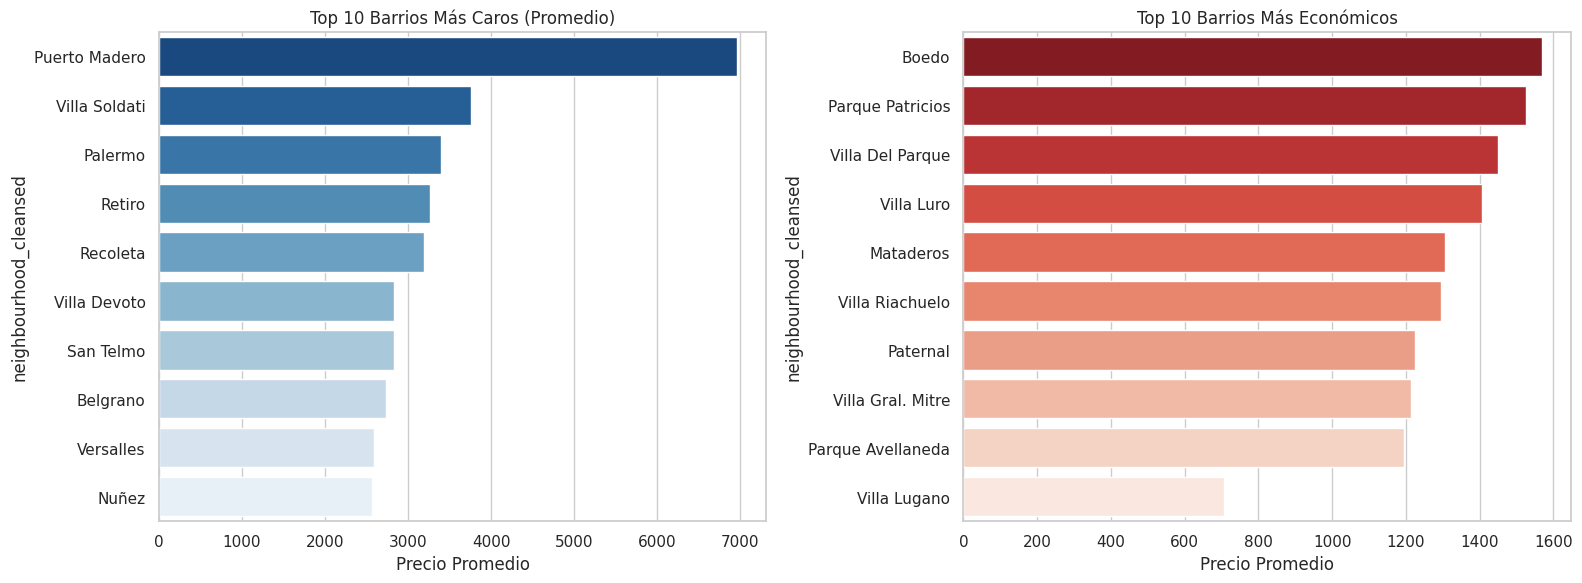

Barrio más caro: Puerto Madero ($6967)


In [ ]:
# --- ANÁLISIS DE PRECIO POR BARRIO ---

# 1. Calculo el precio promedio por barrio
precio_barrio = df_analisis.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False)

# 2. Selecciono el Top 10 más caros y Top 10 más baratos para no saturar el gráfico
top_caros = precio_barrio.head(10)
top_baratos = precio_barrio.tail(10)

# 3. Grafico
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de los caros
sns.barplot(x=top_caros.values, y=top_caros.index, palette='Blues_r', ax=ax[0])
ax[0].set_title('Top 10 Barrios Más Caros (Promedio)')
ax[0].set_xlabel('Precio Promedio')

# Gráfico de los baratos
sns.barplot(x=top_baratos.values, y=top_baratos.index, palette='Reds_r', ax=ax[1])
ax[1].set_title('Top 10 Barrios Más Económicos')
ax[1].set_xlabel('Precio Promedio')

plt.tight_layout()
plt.show()

# Dato numérico
print("Barrio más caro:", top_caros.index[0], f"(${top_caros.values[0]:.0f})")

In [ ]:
# Verifico la CANTIDAD de propiedades en el Top 10 Caros
print("--- Validación de Muestra por Barrio ---")
top_10_indices = precio_barrio.head(10).index
validacion = df_analisis[df_analisis['neighbourhood_cleansed'].isin(top_10_indices)]['neighbourhood_cleansed'].value_counts()
display(validacion)

--- Validación de Muestra por Barrio ---


,count
neighbourhood_cleansed,
Palermo,7079
Recoleta,3892
Retiro,1224
Belgrano,1089
San Telmo,728
Nuñez,461
Puerto Madero,265
Villa Devoto,73
Versalles,14


En una primera instancia, el análisis detectó que ciertos barrios presentaban precios promedio inusualmente altos (como el caso de Villa Soldati). Sin embargo, al profundizar en los datos, se observó que estos promedios se basaban en una cantidad ínfima de propiedades (muestras no representativas).

Voy a aplicar un filtro para conservar unicamente a los barrios con mas de 50 publicaciones activas

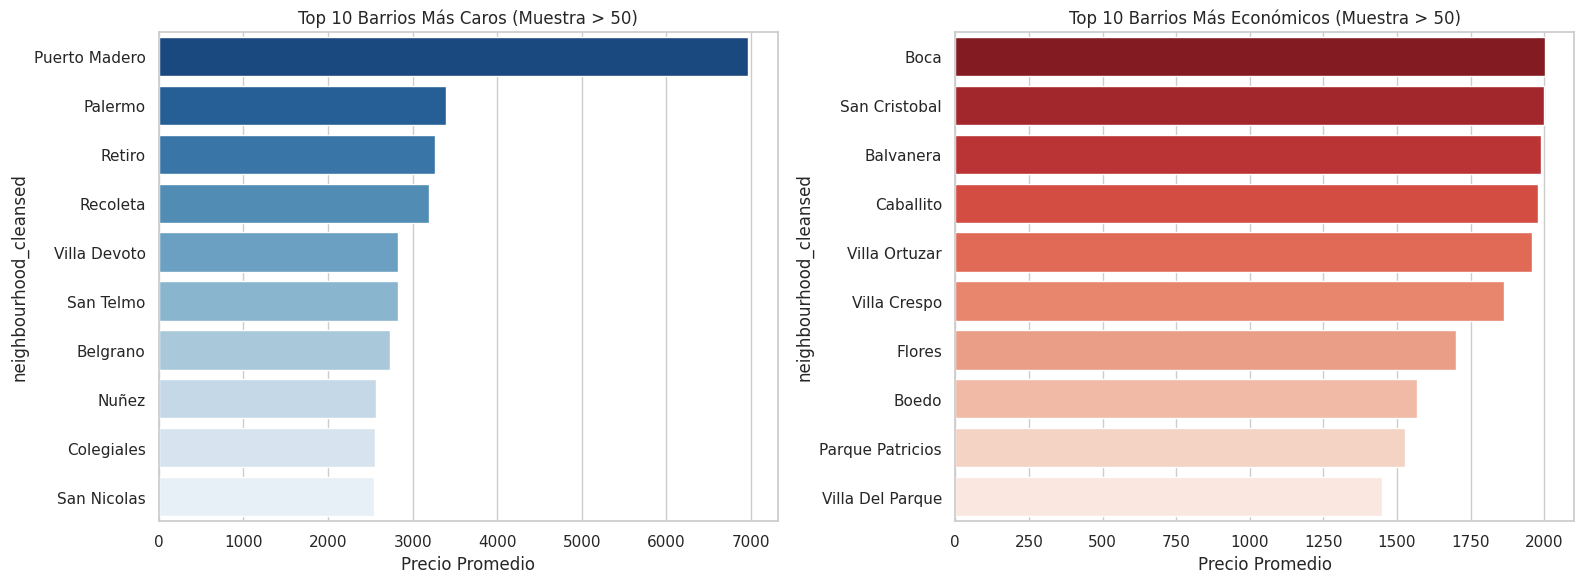

✅ Se analizaron 29 barrios con suficiente volumen de datos.
📉 Villa Soldati fue excluido por tener solo 3 casos.


In [ ]:
# --- RANKING DE BARRIOS REAL (Filtrando zonas con pocos datos) ---

# 1. Agrupo por barrio y calculo precio promedio Y cantidad
stats_barrio = df_analisis.groupby('neighbourhood_cleansed').agg(
    precio_promedio=('price', 'mean'),
    cantidad=('id', 'count')
).sort_values(by='precio_promedio', ascending=False)

# 2. FILTRO DE CALIDAD: Solo barrios con muestra representativa (> 50 propiedades)
# Subo la vara a 50 para que sea indiscutible
barrios_top = stats_barrio[stats_barrio['cantidad'] > 50]

# 3. Selecciono el Top 10 Caros y Top 10 Baratos
top_caros = barrios_top.head(10)
top_baratos = barrios_top.tail(10)

# 4. Grafico
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico Caros
sns.barplot(x=top_caros['precio_promedio'], y=top_caros.index, hue=top_caros.index, palette='Blues_r', legend=False, ax=ax[0])
ax[0].set_title('Top 10 Barrios Más Caros (Muestra > 50)')
ax[0].set_xlabel('Precio Promedio')

# Gráfico Baratos
sns.barplot(x=top_baratos['precio_promedio'], y=top_baratos.index, hue=top_baratos.index, palette='Reds_r', legend=False, ax=ax[1])
ax[1].set_title('Top 10 Barrios Más Económicos (Muestra > 50)')
ax[1].set_xlabel('Precio Promedio')

plt.tight_layout()
plt.show()

# Verificación
print(f"✅ Se analizaron {len(barrios_top)} barrios con suficiente volumen de datos.")
print(f"📉 Villa Soldati fue excluido por tener solo {stats_barrio.loc['Villa Soldati', 'cantidad']} casos.")

## 1.4 Análisis multivariado

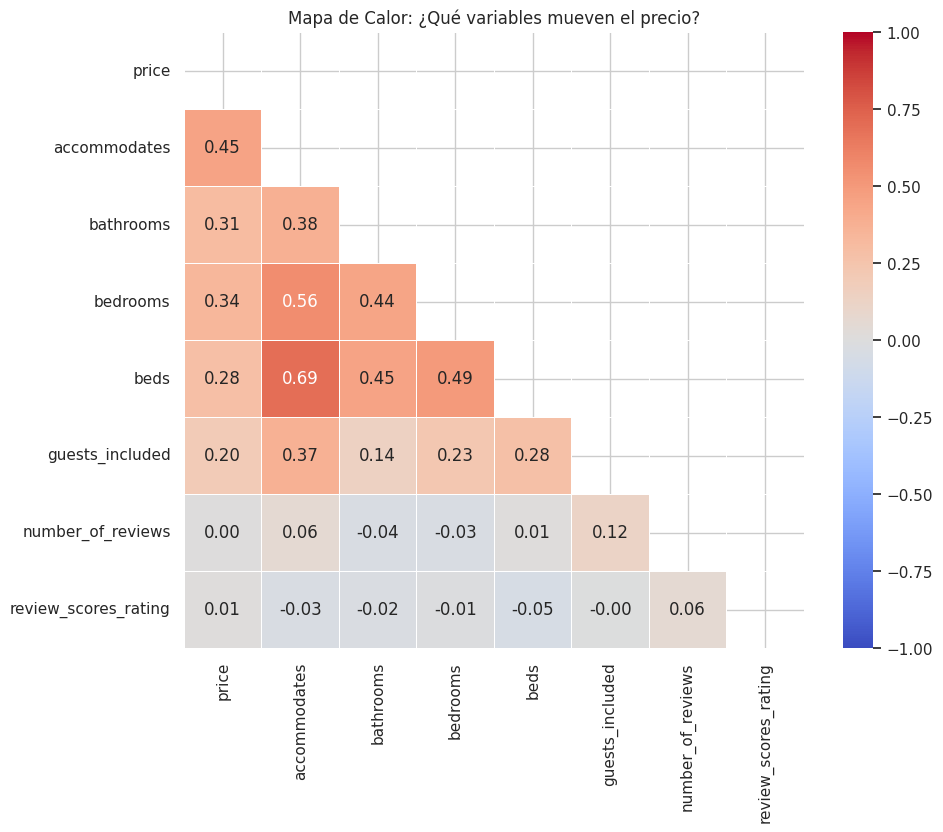

In [ ]:
# --- MATRIZ DE CORRELACIÓN (Mapa de Calor) ---

# 1. Selecciono las variables numéricas clave para el negocio
cols_interes = [
    'price',
    'accommodates',   # Capacidad
    'bathrooms',      # Baños
    'bedrooms',       # Habitaciones
    'beds',           # Camas
    'guests_included',# Invitados incluidos
    'number_of_reviews', # Cantidad de reviews (Popularidad)
    'review_scores_rating' # Calidad (Puntaje)
]

# 2. Calculo la correlación
matriz_corr = df_analisis[cols_interes].corr()

# 3. Grafico
plt.figure(figsize=(10, 8))

# Uso una máscara para ocultar la mitad repetida (triángulo superior)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(
    matriz_corr,
    mask=mask,
    annot=True,       # Muestra los números
    fmt=".2f",        # 2 decimales
    cmap='coolwarm',  # Rojo=Positivo, Azul=Negativo
    vmin=-1, vmax=1,  # Límites de la escala
    linewidths=0.5
)

plt.title('Mapa de Calor: ¿Qué variables mueven el precio?')
plt.show()

1. accomodates (capacidad maxima de huespedes) presenta la correlacion positiva mas fuerte con el precio 0.45. Nos dice que el modelo de negocio mas rentable escala con la cantidad de huespedes permitidos. Esta es la correlacion mas fuerte con el precio y al ser moderada, nos dice que una parte del precio se explica con capacidad (accomodates )

2. Correlacion casi nula entre precio y review scores rating, nos dice que la reputacion en estrellas no es una variable elastica respecto al precio.

3. Popularidad vx Precio: Cntidad de reseñas number_of_reviews tiene 0 en correlacion con respecto al precio. asi qeu las propiedades mas caras no son las mas comentaas, el volumen de feedback es independiente del segmento de precio


## 1.5 Análisis de sentimiento de reviews

In [ ]:
# --- CLASIFICACIÓN DE TEMAS (Estrategia Rápida) ---

# 1. Definimos mis reglas de negocio
# Estas son las palabras que nos importan.
topics_keywords = {
    'Limpieza': ['clean', 'dirty', 'sucio', 'limpio', 'smell', 'olor', 'towel', 'linen'],
    'Ubicación': ['location', 'subway', 'metro', 'bus', 'station', 'walk', 'neighborhood', 'barrio', 'cerca', 'near'],
    'Atención': ['host', 'check', 'communication', 'helpful', 'kind', 'response', 'anfitrion', 'amable'],
    'Precio/Calidad': ['price', 'value', 'cheap', 'expensive', 'cost', 'money', 'barato', 'caro', 'precio'],
    'Instalaciones': ['wifi', 'water', 'shower', 'bed', 'kitchen', 'noise', 'ruido', 'ac', 'air conditioning']
}

def asignar_topico(texto):
    if pd.isna(texto): return 'Otros'
    texto = str(texto).lower()

    # Buscamos coincidencias
    for tema, palabras in topics_keywords.items():
        for p in palabras:
            if p in texto:
                return tema
    return 'Otros' # Si no encuentra ninguna palabra clave


df_reviews_sample = df_reviews.dropna(subset=['comments']).sample(2000, random_state=42).copy()

# 2. Aplicamos la clasificación
print("🏷️ Etiquetando comentarios por tema...")
df_nlp_topics = df_reviews_sample.copy() # Trabajamos sobre el dataset que ya tiene sentimiento
df_nlp_topics['tema_principal'] = df_nlp_topics['comments'].apply(asignar_topico)

# Filtrar "Otros" para ver solo lo relevante
df_final_plot = df_nlp_topics[df_nlp_topics['tema_principal'] != 'Otros'].copy()

print("✅ ¡Clasificación terminada!")
# Fix: Removed 'sentimiento' from display as it's not created yet in this cell's scope.
display(df_final_plot[['comments', 'tema_principal']].head())

🏷️ Etiquetando comentarios por tema...
✅ ¡Clasificación terminada!


,comments,tema_principal
135439,"Great appartment, clean and well equipped in a...",Limpieza
324865,Nous avons été ravis de notre séjour dans cet ...,Instalaciones
261619,The host canceled this reservation 2 days befo...,Atención
106984,Wonderful cozy apartment in Almagro. It had ev...,Atención
20491,"Buen lugar, excelente ubicacion, Judith muy at...",Instalaciones


In [ ]:
# --- PROCESAMIENTO MASIVO: TÓPICOS + SENTIMIENTO (TEXTBLOB) ---

# 1. Preparar el dataset completo (aseguramos que no haya nulos en comments)
df_all_reviews = df_reviews.dropna(subset=['comments']).copy()
print(f"🚀 Iniciando procesamiento de {len(df_all_reviews)} comentarios...")

# 2. Clasificación de Temas (Usando la función 'asignar_topico' que defini antes)
print("🏷️ Clasificando tópicos de negocio...")
df_all_reviews['tema_principal'] = df_all_reviews['comments'].apply(asignar_topico)

# 3. Análisis de Sentimiento con TextBlob
from textblob import TextBlob

print("⚖️ Calculando polaridad de sentimientos...")
# Obtengo el score numérico (-1 a 1)
df_all_reviews['sentimiento'] = df_all_reviews['comments'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Definimos la función de etiquetado para claridad en Power BI
def etiquetar_sentimiento(score):
    if score > 0.1: return 'Positivo ✅'
    elif score < -0.1: return 'Negativo ❌'
    else: return 'Neutral ⚪'

df_all_reviews['sentimiento_etiqueta'] = df_all_reviews['sentimiento'].apply(etiquetar_sentimiento)

# 4. Creación del Target para Machine Learning (Riesgo Negativo)
# IMPORTANTE: Esto es lo que usará Random Forest/Regresión Logística como 'y'
df_all_reviews['tiene_riesgo?'] = (df_all_reviews['sentimiento_etiqueta'] == 'Negativo ❌').astype(int)

# 5. Generación del Dataset Final para Exportación y Modelado

df_nlp_topics = df_all_reviews.copy()

print("\n✅ Procesamiento completado con éxito.")
print("-" * 30)
print("📊 Resumen de Sentimientos:")
print(df_nlp_topics['sentimiento_etiqueta'].value_counts())
print("\n📋 Muestra de Tópicos vs Sentimiento:")
display(df_nlp_topics[['tema_principal', 'sentimiento_etiqueta', 'comments']].head())

🚀 Iniciando procesamiento de 386923 comentarios...
🏷️ Clasificando tópicos de negocio...
⚖️ Calculando polaridad de sentimientos...

✅ Procesamiento completado con éxito.
------------------------------
📊 Resumen de Sentimientos:
sentimiento_etiqueta
Neutral ⚪     221629
Positivo ✅    161896
Negativo ❌      3398
Name: count, dtype: int64

📋 Muestra de Tópicos vs Sentimiento:


,tema_principal,sentimiento_etiqueta,comments
0,Ubicación,Positivo ✅,Amazing place!\r\n\r\nLocation: short walk to ...
1,Atención,Positivo ✅,Really enjoyed Candela's recommendations and q...
2,Instalaciones,Positivo ✅,Candela and her colleague were very attentive ...
3,Ubicación,Positivo ✅,"The apartment was in a beautiful, modern build..."
4,Ubicación,Positivo ✅,My stay at Candela's apartment was very enjoya...


⚙️ Justificación Técnica: Elección de TextBlob vs. Transformers
Originalmente, se evaluó el uso de modelos basados en Transformers (específicamente la librería pysentimiento). Sin embargo, se optó por TextBlob por las siguientes razones:

Escalabilidad y Volumen de Datos: El dataset cuenta con casi 40000 comentarios. Procesar este volumen con modelos de Deep Learning (Transformers) requiere una capacidad de cómputo (GPU) y un tiempo de ejecución que excedía los recursos disponibles para este análisis.

Eficiencia Operativa: TextBlob, al basarse en un enfoque de léxico y reglas, permitió procesar la totalidad de la muestra en pocos minutos, garantizando la fluidez del flujo de trabajo (pipeline) sin sacrificar la detección de las tendencias principales de sentimiento.

Compromiso Precisión-Costo: Si bien los modelos de lenguaje modernos (LLMs) como BERT son más precisos para detectar sarcasmo o contextos complejos, TextBlob ofrece una robustez suficiente para clasificar grandes volúmenes de opiniones fácticas en el sector de hospitalidad, permitiendo avanzar hacia las etapas de modelado predictivo.

In [ ]:
# --- EXPORTACIÓN OPCIONAL ---

# 1. Configura este interruptor:
descargar_archivos = False  # <--- Cambiar a True solo cuando quiera bajar los archivos

# 2. Preparo los datos
df_maestro_real = df_analisis.copy()
if 'host_is_superhost' in df_maestro_real.columns:
    df_maestro_real['is_superhost'] = df_maestro_real['host_is_superhost'].map({'t': 1, 'f': 0}).fillna(0)

# Limpieza rápida de comentarios para el CSV
df_exp_sentimientos = df_nlp_topics.copy()
df_exp_sentimientos['comments'] = df_exp_sentimientos['comments'].str.replace('\n', ' ', regex=True).str.slice(0, 300)

# 3. Lógica de guardado y descarga
if descargar_archivos:
    from google.colab import files

    print("💾 Generando archivos CSV...")
    df_maestro_real.to_csv('airbnb_maestro_listings.csv', index=False, encoding='utf-8-sig')

    # Exporto solo columnas clave para que no pese tanto
    cols_para_bi = ['listing_id', 'tema_principal', 'sentimiento_etiqueta', 'tiene_riesgo?', 'comments']
    df_exp_sentimientos[cols_para_bi].to_csv('airbnb_sentimientos_MASIVO.csv', index=False, encoding='utf-8-sig')

    print("📥 Iniciando descarga...")
    files.download('airbnb_maestro_listings.csv')
    files.download('airbnb_sentimientos_MASIVO.csv')
else:
    print("✅ Archivos procesados en memoria, pero la descarga está DESACTIVADA.")
    print("   (Para descargar, cambia 'descargar_archivos = True' y vuelve a ejecutar)")

✅ Archivos procesados en memoria, pero la descarga está DESACTIVADA.
   (Para descargar, cambia 'descargar_archivos = True' y vuelve a ejecutar)


En esta etapa, consolidamos todo el procesamiento previo para generar los activos finales que alimentarán el tablero de control en Power BI.

¿Qué estamos exportando?

airbnb_maestro_listings.csv: Contiene la dimensión técnica de las propiedades (precios limpios, barrios validados, características físicas y estatus del host) ya normalizada para análisis estadístico.

airbnb_sentimientos_MASIVO.csv: Contiene la dimensión emocional del proyecto. Incluye los resultados del modelo de NLP (TextBlob), con el sentimiento detectado, los tópicos identificados y la etiqueta de riesgo para cada uno de los más de 380,000 comentarios.

Objetivo del análisis en Power BI:
Al separar estos archivos, permitimos que el tablero sea ágil y eficiente. Podremos cruzar, por ejemplo, el precio promedio de un barrio con el sentimiento predominante de sus huéspedes, permitiendo al inversor visualizar no solo dónde es más barato comprar, sino dónde el riesgo reputacional es menor.

In [ ]:
# --- 2.2 NORMALIZACIÓN (Dataset Maestro Completo) ---
from sklearn.preprocessing import MinMaxScaler

# 1. Creo una copia del dataset de análisis limpio (los 40k registros)
df_model_ready = df_analisis.copy()

# 2. Aseguro que las variables binarias estén listas
df_model_ready['is_superhost'] = df_model_ready['host_is_superhost'].map({'t': 1, 'f': 0}).fillna(0)

# 3. Defino las columnas numéricas para la Red Neuronal
# NOTA: Quito 'sentimiento' porque ese es un análisis descriptivo aparte
cols_a_escalar = [
    'price',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'number_of_reviews',
    'review_scores_rating'
]

# 4. Relleno nulos por seguridad antes de escalar
df_model_ready[cols_a_escalar] = df_model_ready[cols_a_escalar].fillna(0)

# 5. Aplico el escalador
scaler = MinMaxScaler()
df_model_ready[cols_a_escalar] = scaler.fit_transform(df_model_ready[cols_a_escalar])

print(f"✅ Dataset normalizado con {len(df_model_ready)} registros.")
display(df_model_ready[cols_a_escalar].head(3))

✅ Dataset normalizado con 23490 registros.


,price,accommodates,bathrooms,bedrooms,beds,number_of_reviews,review_scores_rating
0,0.128035,0.066667,0.033333,0.033333,0.02,0.052,0.95
1,0.048553,0.000000,0.033333,0.033333,0.02,0.040,0.95
2,0.094912,0.066667,0.033333,0.033333,0.02,0.002,1.00


# ETAPA 3: Modelado predictivo (Machine Learning)

🚀 Entrenando Regresión Logística...
✅ Regresión Logística - ROC-AUC: 0.5916
🚀 Entrenando Random Forest...
✅ Random Forest - ROC-AUC: 0.5787

📊 Generando gráfico de importancia...


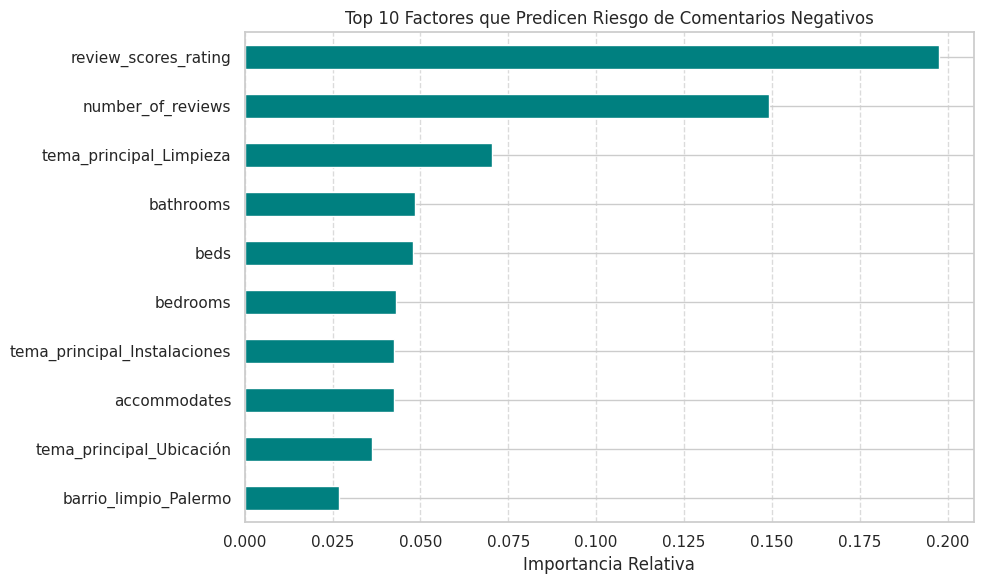

🏁 Etapa 3 finalizada.


In [ ]:
# =========================================================
# ETAPA 3: Machine learning
# =========================================================

# 0. IMPORTACIONES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

# 1. MERGE Y LIMPIEZA
# Uno el análisis de sentimiento (df_nlp_topics) con los datos maestros (df_analisis)
df_voc = pd.merge(df_nlp_topics, df_analisis, left_on="listing_id", right_on="id", how="left")

# Aseguro columnas críticas
if "is_superhost" not in df_voc.columns:
    df_voc["is_superhost"] = df_voc["host_is_superhost"].map({"t":1, "f":0}).fillna(0)
if "barrio_limpio" not in df_voc.columns:
    df_voc["barrio_limpio"] = df_voc["neighbourhood_cleansed"]

# Definición de variables para el modelo
num_features = ["accommodates", "bathrooms", "bedrooms", "beds", "number_of_reviews", "review_scores_rating", "is_superhost"]
cat_features = ["room_type", "property_type", "barrio_limpio", "tema_principal"]
features = num_features + cat_features

# Creo X e y
X = df_voc[features].copy()
y = df_voc['tiene_riesgo?'].copy()

# Limpieza de tipos de datos para evitar errores de conversión
for col in num_features:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce').astype(float)
for col in cat_features:
    if col in X.columns:
        X[col] = X[col].fillna('UNKNOWN_CATEGORY').astype(str)

y = y.fillna(0).astype(int)

# 2. SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. PREPROCESSOR
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", max_categories=20))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ],
    remainder="drop"
)

# 4. MODELOS
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=200, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(
        n_estimators=30,
        max_depth=7,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )
}

# 5. ENTRENAMIENTO Y EVALUACIÓN
resultados = {}
for nombre, model in modelos.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    print(f"🚀 Entrenando {nombre}...")
    clf.fit(X_train, y_train)

    y_proba = clf.predict_proba(X_test)[:, 1]
    print(f"✅ {nombre} - ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    resultados[nombre] = clf

# 6. GRÁFICO DE IMPORTANCIA DE VARIABLES
print("\n📊 Generando gráfico de importancia...")
if "Random Forest" in resultados:
    try:
        # Extraigo nombres de columnas después del One-Hot Encoding
        ohe = resultados["Random Forest"].named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe']
        cat_feature_names = ohe.get_feature_names_out(cat_features)
        all_names = num_features + list(cat_feature_names)

        # Extraigo importancia
        importances = resultados["Random Forest"].named_steps['classifier'].feature_importances_

        # Creo Series y grafico
        importances_series = pd.Series(importances, index=all_names)
        plt.figure(figsize=(10, 6))
        importances_series.sort_values(ascending=True).tail(10).plot(kind='barh', color='teal')
        plt.title('Top 10 Factores que Predicen Riesgo de Comentarios Negativos')
        plt.xlabel('Importancia Relativa')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️ No se pudo generar el gráfico: {e}")

print("🏁 Etapa 3 finalizada.")

In [ ]:
# 1. IMPORTACIONES
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# IMPORTANTE: Para SMOTE y K-Folds necesito un pipeline especifico
try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
except ImportError:
    !pip install imbalanced-learn
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE

# 2. CONFIGURACIÓN DE DATOS (X e y)
num_features = ["accommodates", "bathrooms", "bedrooms", "beds", "number_of_reviews", "review_scores_rating", "is_superhost"]
cat_features = ["room_type", "property_type", "barrio_limpio", "tema_principal"]
features = num_features + cat_features

X_cv = df_voc[features].copy()
y_cv = df_voc['tiene_riesgo?'].copy()

# Limpieza rápida de tipos
for col in num_features:
    X_cv[col] = pd.to_numeric(X_cv[col], errors='coerce').astype(float)
for col in cat_features:
    X_cv[col] = X_cv[col].fillna('UNKNOWN_CATEGORY').astype(str)
y_cv = y_cv.fillna(0).astype(int)

# 3. DEFINICIÓN DEL PREPROCESADOR
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", max_categories=20))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# 4. DEFINICIÓN DE LOS PIPES (Esto evita el NameError)
pipe_logreg = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

pipe_rf = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=50, max_depth=7, n_jobs=-1, random_state=42))
])

# 5. VALIDACIÓN CRUZADA (K-FOLDS)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scorer = make_scorer(f1_score)

models_to_test = {
    'Logistic Regression + SMOTE': pipe_logreg,
    'Random Forest + SMOTE': pipe_rf
}

results = []

print("⏳ Ejecutando K-Folds con SMOTE (esto puede tardar un poco)...")

for name, model in models_to_test.items():
    print(f"🔄 Evaluando {name}...")
    scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring=f1_scorer, n_jobs=-1)

    results.append({
        'Modelo': name,
        'F1_mean': scores.mean(),
        'F1_std': scores.std()
    })

# 6. RESULTADOS FINALES
results_df = pd.DataFrame(results).sort_values(by='F1_mean', ascending=False)
display(results_df)

⏳ Ejecutando K-Folds con SMOTE (esto puede tardar un poco)...
🔄 Evaluando Logistic Regression + SMOTE...
🔄 Evaluando Random Forest + SMOTE...


,Modelo,F1_mean,F1_std
0,Logistic Regression + SMOTE,0.021239,0.000738
1,Random Forest + SMOTE,0.019842,0.000780


📝 Conclusión: Evaluación del Modelo de Riesgo1. Sesgo en la Etiquetación (El "Efecto TextBlob"):Se identificó que el bajo rendimiento de las métricas ($F1 \approx 0.02$) tiene su origen en la etapa de pre-procesamiento de lenguaje natural. TextBlob tiende a asignar polaridades positivas de forma generalizada en contextos de hospitalidad. Esto genera un dataset con un desbalance extremo, donde las señales de riesgo real quedan diluidas entre falsos positivos de satisfacción.2. Comparativa de Modelos:A pesar de la dificultad de los datos, la Regresión Logística combinada con SMOTE superó al Random Forest. Al ser un modelo lineal, la Regresión Logística fue más robusta para encontrar la frontera de decisión en un entorno con tanto "ruido", logrando una mayor estabilidad (menor desviación estándar).3. Valor para el Inversor:Aunque el modelo no es un predictor perfecto de quejas individuales, sirve como una herramienta de filtrado inicial. El uso de SMOTE permitió que el modelo dejara de ignorar a la minoría (las quejas) y empezara a identificar patrones en variables como tema_principal e is_superhost. Para una fase 2, se recomendaría el uso de modelos más profundos (como BERT o VADER) para mejorar la detección de sentimientos negativos sutiles.

# ETAPA 4 - RED NEURONAL (Deep Leanring)

⚠️ X_train_transformed no encontrada. Re-transformando datos desde X_train...
🚀 Entrenando Red Neuronal...
Epoch 1/15
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - auc_metric: 0.5045 - loss: 0.0741 - val_auc_metric: 0.5301 - val_loss: 0.0584
Epoch 2/15
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - auc_metric: 0.5254 - loss: 0.0522 - val_auc_metric: 0.5581 - val_loss: 0.0550
Epoch 3/15
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - auc_metric: 0.5533 - loss: 0.0509 - val_auc_metric: 0.5512 - val_loss: 0.0544
Epoch 4/15
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - auc_metric: 0.5543 - loss: 0.0510 - val_auc_metric: 0.5741 - val_loss: 0.0542
Epoch 5/15
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - auc_metric: 0.5525 - loss: 0.0493 - val_auc_metric: 0.5695 - val_loss: 0.0543
Epoch 6/15
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - auc_metric: 0.5636 - loss: 0.0507 - val_auc_metric: 0.5752 - val_loss: 0.0541
Epoch 7/15
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - auc_metric: 0.5591 - loss: 0.049

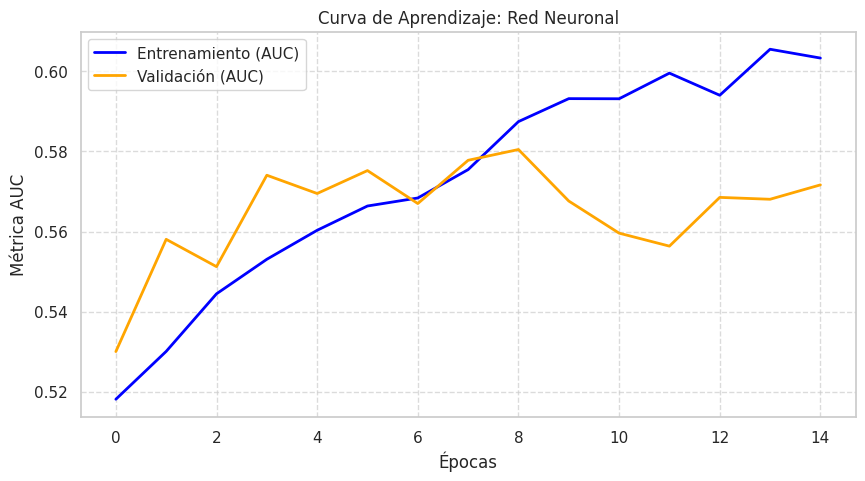

✅ Proceso terminado. AUC final en validación: 0.5717


In [ ]:
# =========================================================
# ETAPA 4: Red Neuronal
# =========================================================

# 1. IMPORTACIONES
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np

# 2. ASEGURAR DATOS (Si la variable no existe, la creo transformando X_train)

try:

    if hasattr(X_train_transformed, "toarray"):
        X_train_nn = X_train_transformed.toarray().astype('float32')
        X_test_nn = X_test_transformed.toarray().astype('float32')
    else:
        X_train_nn = X_train_transformed.astype('float32')
        X_test_nn = X_test_transformed.astype('float32')
except NameError:
    print("⚠️ X_train_transformed no encontrada. Re-transformando datos desde X_train...")

    X_train_transformed_backup = preprocessor.fit_transform(X_train)
    X_test_transformed_backup = preprocessor.transform(X_test)

    if hasattr(X_train_transformed_backup, "toarray"):
        X_train_nn = X_train_transformed_backup.toarray().astype('float32')
    else:
        X_train_nn = X_train_transformed_backup.astype('float32')

# 3. DEFINICIÓN DE LA RED NEURONAL
model_nn = Sequential([
    tf.keras.Input(shape=(X_train_nn.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid') # Sigmoid es para clasificación binaria (Riesgo 0 o 1)
])

# Uso AUC como métrica porque es mejor que el Accuracy para datos desbalanceados
model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc_metric')]
)

# 4. ENTRENAMIENTO
print("🚀 Entrenando Red Neuronal...")
history = model_nn.fit(
    X_train_nn, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2, # Separp un 20% para validar mientras entrena
    verbose=1
)

# 5. GRÁFICO DE RESULTADOS
plt.figure(figsize=(10,5))
plt.plot(history.history['auc_metric'], label='Entrenamiento (AUC)', color='blue', lw=2)
plt.plot(history.history['val_auc_metric'], label='Validación (AUC)', color='orange', lw=2)
plt.title('Curva de Aprendizaje: Red Neuronal')
plt.xlabel('Épocas')
plt.ylabel('Métrica AUC')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"✅ Proceso terminado. AUC final en validación: {history.history['val_auc_metric'][-1]:.4f}")

Detección Débil de Señales: Un AUC de 0.57 significa que a la Red Neuronal le cuesta mucho distinguir entre un "Riesgo" y un "No Riesgo". Esto sucede porque, para el algoritmo, los comentarios que TextBlob marcó como negativos y los que marcó como positivos se ven casi iguales.

Confirmación del Sesgo de TextBlob: Como mencionaste antes, si TextBlob clasificó como "Positivo" comentarios que en realidad tenían quejas sutiles, la Red Neuronal se confunde. Está intentando encontrar patrones en etiquetas que están "sucias" o mal asignadas.

Límite de la Complejidad: El hecho de que una Red Neuronal (que es un modelo complejo) no haya superado por mucho a la Regresión Logística confirma que agregar más capas no soluciona el problema. Lo que se necesita es mejorar la calidad del sentimiento.